<a href="https://colab.research.google.com/github/gunjancs23149/Machine-Learing-Project/blob/main/RANDOM_FOREST_CS23139.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Saved from Chrome/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv')
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410


In [ ]:
print('--- DataFrame Info ---')
df.info()
print('\n--- Descriptive Statistics ---')
df.describe()
print('\n--- Missing Values ---')
df.isnull().sum()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 716.4+ KB

--- Descriptive Statistics ---

--- Missing Values ---


,0
Circle,0
Division,0
SubDivision,0
Section,0
Area,0
CatCode,0
CatDesc,0
TotServices,0
BilledServices,0
Units,0


In [ ]:
df['Year'] = 2025
df['Month'] = 1

print("Added 'Year' and 'Month' columns.")
df.head()

Added 'Year' and 'Month' columns.


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load,Year,Month
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000,2025,1
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100,2025,1
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730,2025,1
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578,2025,1
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410,2025,1


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features encoded successfully. Displaying first 5 rows of the encoded DataFrame:")
df_encoded.head()

Categorical features encoded successfully. Displaying first 5 rows of the encoded DataFrame:


,CatCode,TotServices,BilledServices,Units,Load,Year,Month,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,...,Area_ZOORPOOR,Area_ZP OFFICE AREA,Area_battilagumpu,Area_chadmal thanda,Area_chintala thanda,Area_dammakkapeta,Area_gurjalthanda,Area_guttamallaram,Area_laxmicolony,Area_vrn thanda
0,2,5,5,84,11.000,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,392,334,44762,872.100,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,492,431,31931,568.730,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,458,407,28871,657.578,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2,326,262,111598,2199.410,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X = df_encoded.drop('Load', axis=1)
y = df_encoded['Load']

print("Features (X) and target variable (y) defined successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target variable (y) defined successfully.
Shape of X: (8335, 7858)
Shape of y: (8335,)


## 80:20 Train-Test Split

### Subtask:
Split the data into training and testing sets with an 80:20 ratio using `train_test_split`.


In [ ]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into 80:20 training and testing sets successfully.")
print(f"Shape of X_train_80: {X_train_80.shape}")
print(f"Shape of X_test_80: {X_test_80.shape}")
print(f"Shape of y_train_80: {y_train_80.shape}")
print(f"Shape of y_test_80: {y_test_80.shape}")

Data split into 80:20 training and testing sets successfully.
Shape of X_train_80: (6668, 7858)
Shape of X_test_80: (1667, 7858)
Shape of y_train_80: (6668,)
Shape of y_test_80: (1667,)


In [ ]:
scaler_80 = StandardScaler()
X_train_scaled_80 = scaler_80.fit_transform(X_train_80)
X_test_scaled_80 = scaler_80.transform(X_test_80)

print("Features scaled successfully for the 80:20 split.")
print(f"Shape of X_train_scaled_80: {X_train_scaled_80.shape}")
print(f"Shape of X_test_scaled_80: {X_test_scaled_80.shape}")

Features scaled successfully for the 80:20 split.
Shape of X_train_scaled_80: (6668, 7858)
Shape of X_test_scaled_80: (1667, 7858)


In [ ]:
model_80 = RandomForestRegressor(random_state=42)
model_80.fit(X_train_scaled_80, y_train_80)

y_pred_80 = model_80.predict(X_test_scaled_80)

mae_80 = mean_absolute_error(y_test_80, y_pred_80)
mse_80 = mean_squared_error(y_test_80, y_pred_80)
rmse_80 = np.sqrt(mse_80)
r2_80 = r2_score(y_test_80, y_pred_80)

performance_80_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae_80, mse_80, rmse_80, r2_80]
})

print("Random Forest Regressor Performance (80:20 Split):")
print(performance_80_df.to_string(index=False))

Random Forest Regressor Performance (80:20 Split):
   Metric       Value
      MAE   23.363508
      MSE 5541.531105
     RMSE   74.441461
R-squared    0.979673


In [ ]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data split into 70:30 training and testing sets successfully.")
print(f"Shape of X_train_70: {X_train_70.shape}")
print(f"Shape of X_test_70: {X_test_70.shape}")
print(f"Shape of y_train_70: {y_train_70.shape}")
print(f"Shape of y_test_70: {y_test_70.shape}")

Data split into 70:30 training and testing sets successfully.
Shape of X_train_70: (5834, 7858)
Shape of X_test_70: (2501, 7858)
Shape of y_train_70: (5834,)
Shape of y_test_70: (2501,)


```markdown
## Feature Scaling (70:30 Split)

### Subtask:
Apply `StandardScaler` to scale the features for the 70:30 train-test split.
```

In [ ]:
scaler_70 = StandardScaler()
X_train_scaled_70 = scaler_70.fit_transform(X_train_70)
X_test_scaled_70 = scaler_70.transform(X_test_70)

print("Features scaled successfully for the 70:30 split.")
print(f"Shape of X_train_scaled_70: {X_train_scaled_70.shape}")
print(f"Shape of X_test_scaled_70: {X_test_scaled_70.shape}")

Features scaled successfully for the 70:30 split.
Shape of X_train_scaled_70: (5834, 7858)
Shape of X_test_scaled_70: (2501, 7858)


In [ ]:
model_70 = RandomForestRegressor(random_state=42)
model_70.fit(X_train_scaled_70, y_train_70)

y_pred_70 = model_70.predict(X_test_scaled_70)

mae_70 = mean_absolute_error(y_test_70, y_pred_70)
mse_70 = mean_squared_error(y_test_70, y_pred_70)
rmse_70 = np.sqrt(mse_70)
r2_70 = r2_score(y_test_70, y_pred_70)

performance_70_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae_70, mse_70, rmse_70, r2_70]
})

print("Random Forest Regressor Performance (70:30 Split):")
print(performance_70_df.to_string(index=False))

Random Forest Regressor Performance (70:30 Split):
   Metric       Value
      MAE   24.157235
      MSE 6856.679491
     RMSE   82.805069
R-squared    0.972204


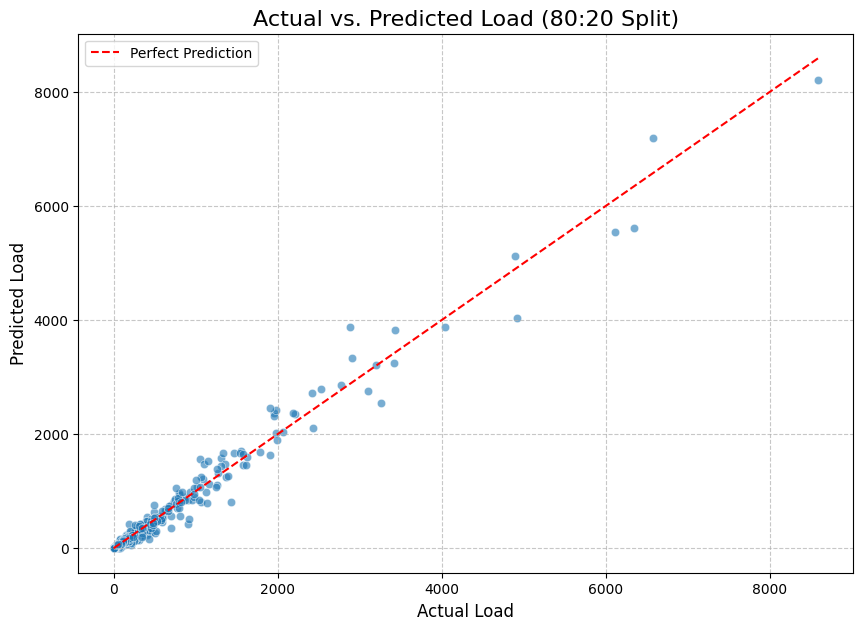

Scatter plot for actual vs. predicted load (80:20 split) displayed successfully.


In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_80, y=y_pred_80, alpha=0.6)

# Add a diagonal line for perfect predictions
min_val = min(y_test_80.min(), y_pred_80.min())
max_val = max(y_test_80.max(), y_pred_80.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted Load (80:20 Split)', fontsize=16)
plt.xlabel('Actual Load', fontsize=12)
plt.ylabel('Predicted Load', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Scatter plot for actual vs. predicted load (80:20 split) displayed successfully.")

In [ ]:
performance_80_df_copy = performance_80_df.copy()
performance_80_df_copy['Split'] = '80:20'

performance_70_df_copy = performance_70_df.copy()
performance_70_df_copy['Split'] = '70:30'

combined_performance_df = pd.concat([performance_80_df_copy, performance_70_df_copy], ignore_index=True)

print("Combined performance DataFrame created successfully:")
combined_performance_df.head()

Combined performance DataFrame created successfully:


,Metric,Value,Split
0,MAE,23.363508,80:20
1,MSE,5541.531105,80:20
2,RMSE,74.441461,80:20
3,R-squared,0.979673,80:20
4,MAE,24.157235,70:30


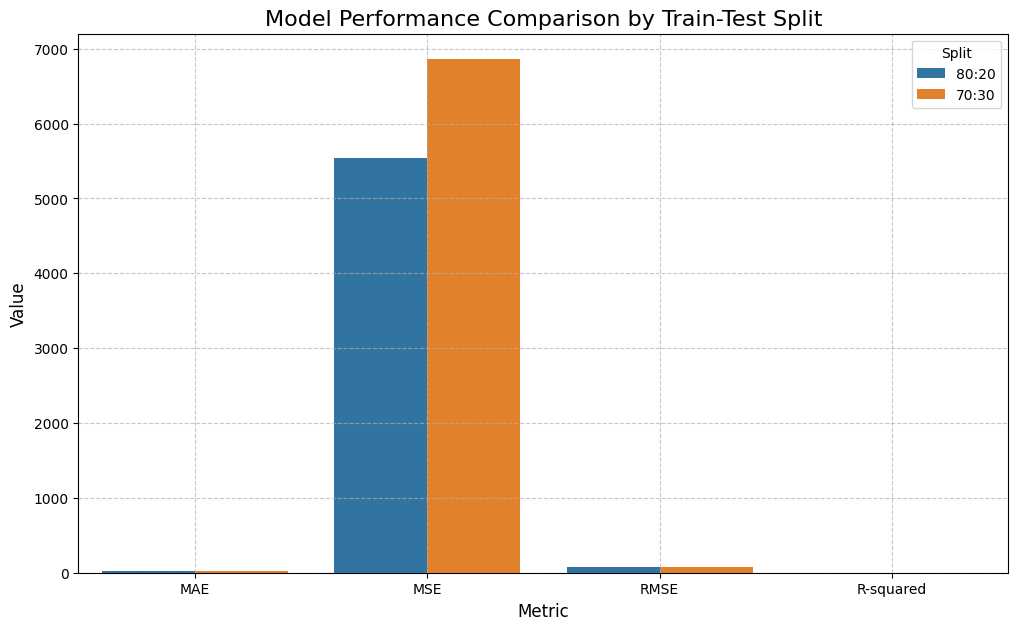

Bar chart comparing model performance metrics displayed successfully.


In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='Split', data=combined_performance_df)
plt.title('Model Performance Comparison by Train-Test Split', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(title='Split')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Bar chart comparing model performance metrics displayed successfully.")

## Summarize Performance Comparison

### Subtask:
Analyze and summarize the performance metrics, comparing the MAE, MSE, RMSE, and R-squared values between the 80:20 and 70:30 splits. Discuss which split resulted in a better-performing model and provide insights into the observed differences.


In [ ]:
feature_importances = model_80.feature_importances_
feature_names = X.columns

feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances (80:20 Split):")
feature_importances_df.head(10)

Top 10 Feature Importances (80:20 Split):


,Feature,Importance
3,Units,0.951794
1,TotServices,0.025416
2,BilledServices,0.010035
1300,Area_BHADRACHALAM,0.000847
216,Section_BCM-TOWN,0.000770
25,Division_BHADRACHALAM,0.000533
43,Division_MANCHERIAL,0.000482
6930,Area_STHAMBHAMPALLI,0.000354
449,Section_MANCHIRIAL TOWN2,0.000306
699,Area_ADILABAD - SOUTH,0.000254


**Reasoning**:
To visualize the top N most important features, I will create a bar plot using the `feature_importances_df` DataFrame, showing the top 10 features sorted by their importance.



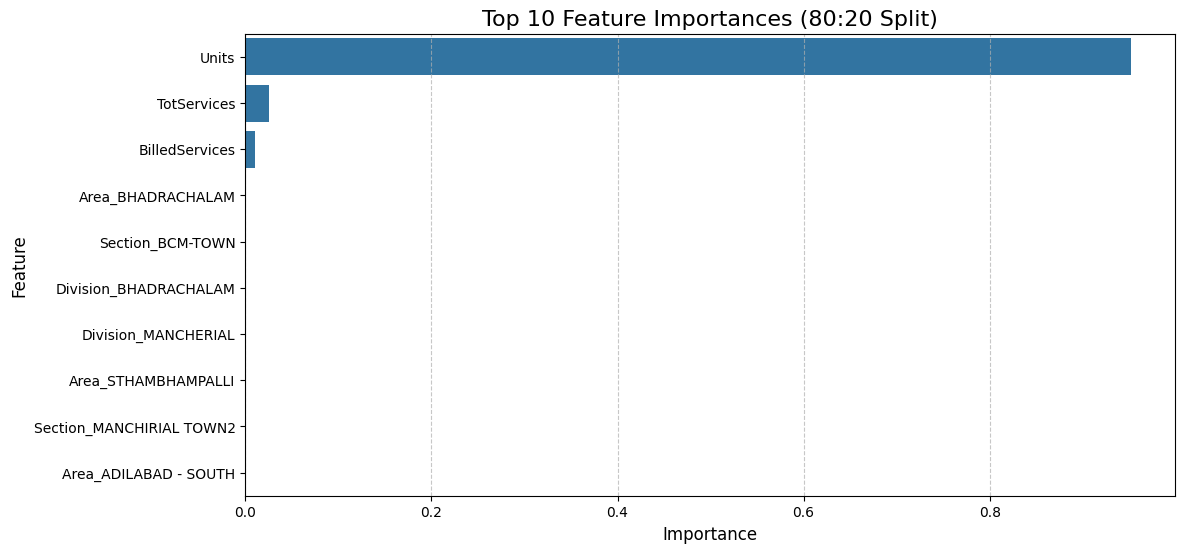

Bar chart of top 10 feature importances displayed successfully.


In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(10))
plt.title('Top 10 Feature Importances (80:20 Split)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
print("Bar chart of top 10 feature importances displayed successfully.")